In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Ambiente configurado com sucesso!")

Ambiente configurado com sucesso!


In [39]:
caminho = "../Dados/LOGS_EVENTOS.txt"

with open(caminho, "r", encoding="utf-8") as arquivo:
    linhas = arquivo.readlines()

print(f"Quantidade de linhas: {len(linhas)}")
print("\nPrimeiras 5 linhas:")
print("".join(linhas[:5]))

Quantidade de linhas: 10000

Primeiras 5 linhas:
YBDMF  -2014/08/11 18:47:35 543-0-1-0-000-0
ENBAY  -2014/08/11 18:47:35 863-1-1-0-300-0
VNMDB  -2014/08/11 18:47:35 866-1-1-0-300-0
TULKG  -2014/08/11 18:47:35 871-1-1-0-300-0
WDNPJ  -2014/08/11 18:47:36 355-0-1-0-000-0



In [40]:
import re

registros = []

for linha in linhas:
    linha = linha.strip()

    padrao = r"^(\w+)\s+-([\d/]+)\s+([\d:]+)\s+(.+)$"
    resultado = re.match(padrao, linha)

    if resultado:
        identificador, data, hora, evento = resultado.groups()

        registros.append([
            identificador,
            data,
            hora,
            evento
        ])

df = pd.DataFrame(
    registros,
    columns=[
        "identificador",
        "data",
        "hora",
        "evento"
    ]
)

df.head()

,identificador,data,hora,evento
0,YBDMF,2014/08/11,18:47:35,543-0-1-0-000-0
1,ENBAY,2014/08/11,18:47:35,863-1-1-0-300-0
2,VNMDB,2014/08/11,18:47:35,866-1-1-0-300-0
3,TULKG,2014/08/11,18:47:35,871-1-1-0-300-0
4,WDNPJ,2014/08/11,18:47:36,355-0-1-0-000-0


In [41]:
identificadores = df["identificador"].unique()
print(identificadores)

print("Quantidade de identificadores:", df["identificador"].nunique())


<StringArray>
[ 'YBDMF',  'ENBAY',  'VNMDB',  'TULKG',  'WDNPJ',  'JKPIB',  'JKDQV',
 'KEJRWS', 'NFPHYZ',  'WXZHS',
 ...
   'YQGS',  'UOZHI',  'OXYTY',  'MBMSX',  'RWWTZ',  'NIYZU',  'ERRDF',
   'LWMN',  'PLZTD',  'WODAA']
Length: 707, dtype: str
Quantidade de identificadores: 707


In [42]:
maisfrequente = df["identificador"].value_counts().head(10).reset_index()
menosfrequente = df["identificador"].value_counts().tail(10).reset_index()
maisfrequente.columns = ["Identificador mais frequente","Quantidade"]
menosfrequente.columns = ["Identificador menos frequente","Quantidade"]
print(maisfrequente.to_string(index=False, justify="center"))
print()
print(menosfrequente.to_string(index=False,  justify="center"))

Identificador mais frequente  Quantidade
           JRJDD                 1875   
           WDWIL                  945   
           MYJBV                  401   
           HOULM                  368   
           RCEFT                  226   
           URJAC                  203   
           GYQAW                  192   
           RKHPC                  160   
             HMJ                   96   
           LSFFH                   82   

Identificador menos frequente  Quantidade
            GGUUB                  1     
            HUTKA                  1     
            GERAM                  1     
            LQVMZ                  1     
            RANJB                  1     
            KOHSM                  1     
            NWSTR                  1     
            MDLJJ                  1     
            DQVRC                  1     
             YQGS                  1     


In [43]:
Eventos = df["evento"].unique()
print(Eventos)

print("Quantidade de eventos:", df["evento"].nunique())

<StringArray>
['543-0-1-0-000-0', '863-1-1-0-300-0', '866-1-1-0-300-0', '871-1-1-0-300-0',
 '355-0-1-0-000-0', '484-0-1-0-000-0', '881-0-1-0-300-0', '370-0-1-7-120-0',
 '370-1-1-1-100-0', '370-1-1-1-000-0',
 ...
 '968-1-1-0-100-0', '358-0-1-0-500-0', '605-0-1-0-100-0', '781-1-1-0-700-0',
 '952-1-1-0-300-0', '981-1-1-0-300-0', '990-0-1-0-300-0', '669-0-1-7-120-0',
 '669-1-1-1-100-0', '669-1-1-1-000-0']
Length: 5773, dtype: str
Quantidade de eventos: 5773


In [44]:
maisfrequente = df["evento"].value_counts().head(10).reset_index()
menosfrequente = df["evento"].value_counts().tail(10).reset_index()
maisfrequente.columns = ["Evento mais frequente","Quantidade"]
menosfrequente.columns = ["Evento menos frequente","Quantidade"]
print(maisfrequente.to_string(index=False, justify="center"))
print()
print(menosfrequente.to_string(index=False,  justify="center"))

Evento mais frequente  Quantidade
   669-1-1-1-000-0        750    
   669-1-1-1-100-0        276    
   370-1-1-1-000-0         33    
   581-1-1-1-000-0         33    
   358-1-1-1-000-0         33    
   915-1-1-1-000-0         30    
   669-0-1-7-120-0         26    
   370-1-1-1-100-0         15    
   581-1-1-1-100-0         15    
   358-1-1-1-100-0         12    

Evento menos frequente  Quantidade
   583-0-1-0-700-0          1     
   133-1-1-0-300-0          1     
   143-0-1-0-300-0          1     
   968-1-1-0-100-0          1     
   358-0-1-0-500-0          1     
   605-0-1-0-100-0          1     
   781-1-1-0-700-0          1     
   952-1-1-0-300-0          1     
   981-1-1-0-300-0          1     
   990-0-1-0-300-0          1     


In [63]:
df["timestamp"] = pd.to_datetime(df["data"] + " " + df["hora"],format="%Y/%m/%d %H:%M:%S")
eventos_por_horario = df["timestamp"].value_counts()
print(eventos_por_horario.head(20))

timestamp
2014-08-12 21:29:19    1052
2014-08-11 18:47:57      49
2014-08-11 19:06:01      49
2014-08-12 12:24:06      47
2014-08-12 19:32:33      41
2014-08-12 00:16:29      38
2014-08-12 00:16:22      35
2014-08-12 00:16:28      29
2014-08-12 00:16:30      26
2014-08-12 00:16:18      25
2014-08-11 21:53:56      21
2014-08-11 21:54:40      21
2014-08-11 21:55:09      21
2014-08-12 00:16:24      17
2014-08-12 00:16:23      14
2014-08-12 10:49:58      12
2014-08-11 21:52:45      11
2014-08-11 21:53:36      11
2014-08-11 21:54:18      11
2014-08-11 21:54:58      11
Name: count, dtype: int64


In [67]:
timestamp_pico = eventos_por_horario.idxmax()

eventos_pico = df[df["timestamp"] == timestamp_pico]

print(eventos_pico)
print()
print(eventos_pico["identificador"].value_counts())
print()
print(eventos_pico["evento"].value_counts())

     identificador        data      hora           evento           timestamp  \
8946         JKDQV  2014/08/12  21:29:19  669-0-1-7-120-0 2014-08-12 21:29:19   
8947        KEJRWS  2014/08/12  21:29:19  669-1-1-1-100-0 2014-08-12 21:29:19   
8948        NFPHYZ  2014/08/12  21:29:19  669-1-1-1-100-0 2014-08-12 21:29:19   
8949        QBQUMN  2014/08/12  21:29:19  669-1-1-1-100-0 2014-08-12 21:29:19   
8950        XRIODT  2014/08/12  21:29:19  669-1-1-1-100-0 2014-08-12 21:29:19   
...            ...         ...       ...              ...                 ...   
9993        QIYYFL  2014/08/12  21:29:19  669-1-1-1-000-0 2014-08-12 21:29:19   
9994        WMQMIH  2014/08/12  21:29:19  669-1-1-1-000-0 2014-08-12 21:29:19   
9995        IFAHYT  2014/08/12  21:29:19  669-1-1-1-000-0 2014-08-12 21:29:19   
9996         JKDQV  2014/08/12  21:29:19  669-0-1-7-120-0 2014-08-12 21:29:19   
9997        KEJRWS  2014/08/12  21:29:19  669-1-1-1-100-0 2014-08-12 21:29:19   

      hora_do_dia         d

In [57]:
df["hora_do_dia"] = df["timestamp"].dt.hour
contagem_horas = df["hora_do_dia"].value_counts()

print("Hora com mais eventos:", contagem_horas.idxmax())
print("Quantidade de eventos:", contagem_horas.max())

Hora com mais eventos: 21
Quantidade de eventos: 1636


In [65]:
df["dia"] = df["timestamp"].dt.date
eventos_por_dia = df["dia"].value_counts().sort_index()
print(eventos_por_dia)
print("Dia com mais eventos:", eventos_por_dia.idxmax())
print("Quantidade de eventos:", eventos_por_dia.max())

dia
2014-08-11    1380
2014-08-12    8618
Name: count, dtype: int64
Dia com mais eventos: 2014-08-12
Quantidade de eventos: 8618


In [60]:
horario_mais_frequente = (df.groupby("identificador")["timestamp"].agg(lambda x: x.value_counts().idxmax()))

print(horario_mais_frequente)

identificador
ABEMZ    2014-08-12 06:51:59
ABMKF    2014-08-11 21:04:42
AFPPR    2014-08-12 14:53:02
AIFMTB   2014-08-12 21:29:19
AIZT     2014-08-12 00:05:17
                 ...        
ZXZD     2014-08-12 00:16:18
ZYOWD    2014-08-12 10:32:17
ZYPOA    2014-08-12 01:17:55
ZYVAH    2014-08-12 00:16:22
ZYXO     2014-08-12 00:16:23
Name: timestamp, Length: 707, dtype: datetime64[us]


In [52]:
tabela_horarios = pd.crosstab(df["identificador"],df["hora_do_dia"])

tabela_horarios

hora_do_dia,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
identificador,,,,,,,,,,,,,,,,,,,,,
ABEMZ,0,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ABMKF,0,2,0,0,0,0,0,0,2,0,...,2,0,32,0,0,0,4,22,0,2
AFPPR,0,0,0,0,0,0,0,0,0,0,...,25,0,0,0,0,0,0,0,0,0
AIFMTB,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,2,0,25,0,0
AIZT,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZXZD,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZYOWD,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZYPOA,0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


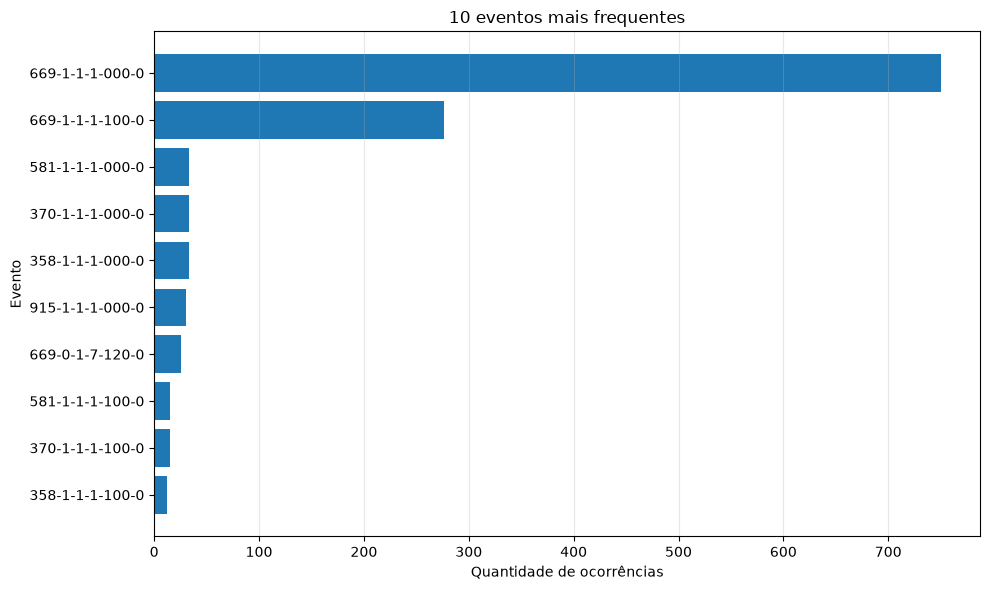

In [68]:
eventos_frequentes = (df["evento"].value_counts().head(10).sort_values())

plt.figure(figsize=(10, 6))

plt.barh(eventos_frequentes.index,eventos_frequentes.values)

plt.xlabel("Quantidade de ocorrências")
plt.ylabel("Evento")
plt.title("10 eventos mais frequentes")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

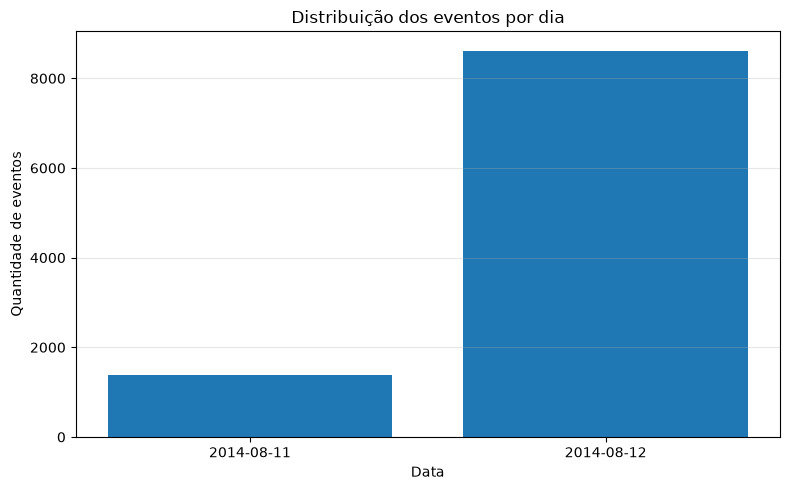

In [69]:
eventos_por_dia = (df["dia"].value_counts().sort_index())

plt.figure(figsize=(8, 5))

plt.bar(eventos_por_dia.index.astype(str), eventos_por_dia.values)

plt.xlabel("Data")
plt.ylabel("Quantidade de eventos")
plt.title("Distribuição dos eventos por dia")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

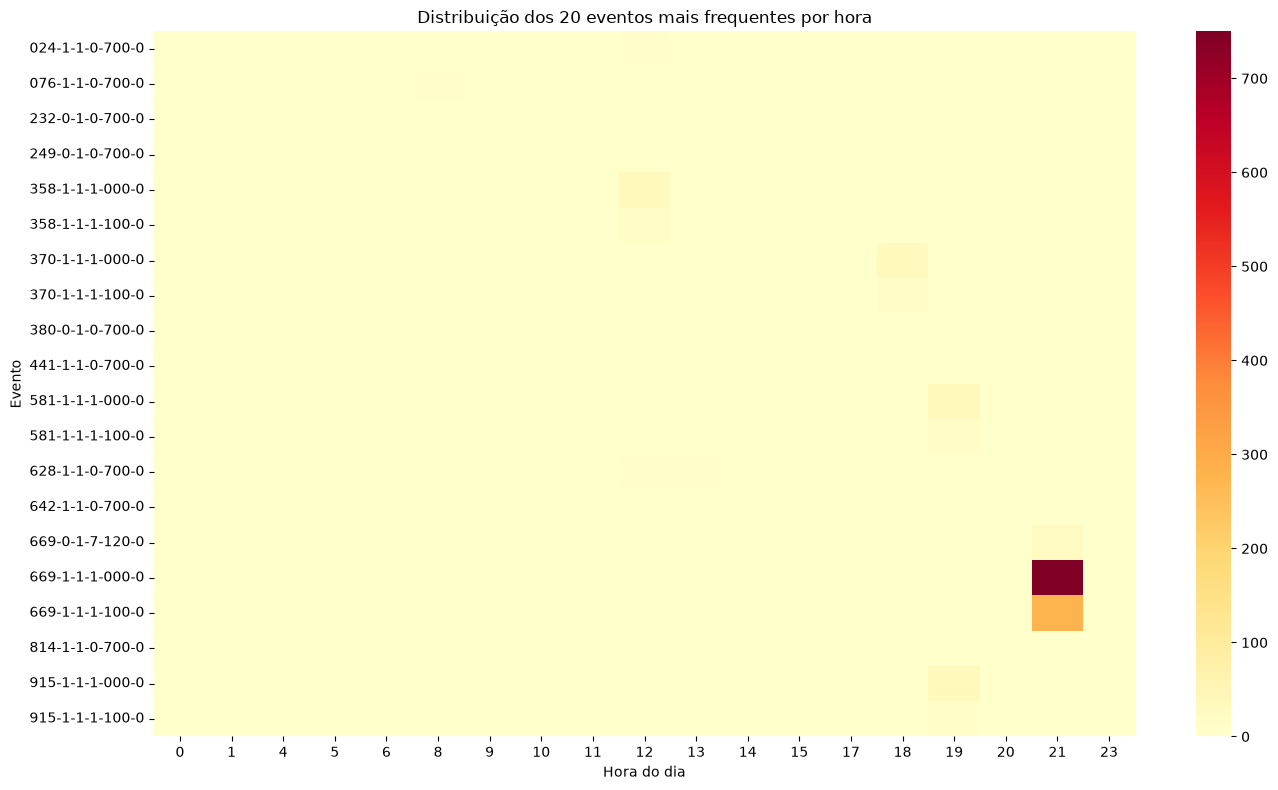

In [71]:
eventos_principais = (df["evento"].value_counts().head(20).index)

tabela_eventos_hora = pd.crosstab(df[df["evento"].isin(eventos_principais)]["evento"],df[df["evento"].isin(eventos_principais)]["hora_do_dia"])

plt.figure(figsize=(14, 8))

sns.heatmap(tabela_eventos_hora,cmap="YlOrRd")

plt.xlabel("Hora do dia")
plt.ylabel("Evento")
plt.title("Distribuição dos 20 eventos mais frequentes por hora")

plt.tight_layout()
plt.show()

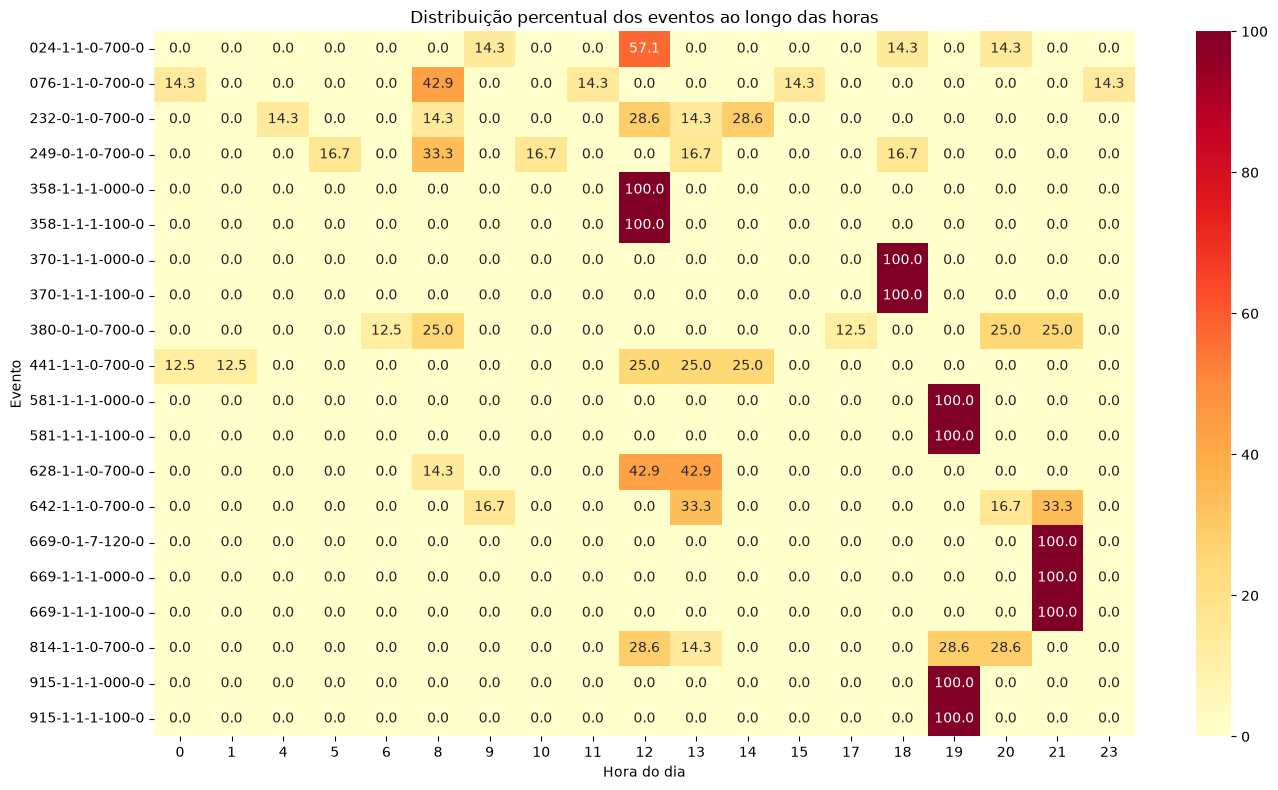

In [72]:
eventos_principais = (df["evento"].value_counts().head(20).index)
df_principais = df[df["evento"].isin(eventos_principais)]

tabela_eventos_hora = pd.crosstab(df_principais["evento"],df_principais["hora_do_dia"])
tabela_percentual = (tabela_eventos_hora.div(tabela_eventos_hora.sum(axis=1), axis=0)* 100)

plt.figure(figsize=(14, 8))

sns.heatmap(tabela_percentual,cmap="YlOrRd",annot=True,fmt=".1f")

plt.xlabel("Hora do dia")
plt.ylabel("Evento")
plt.title("Distribuição percentual dos eventos ao longo das horas")

plt.tight_layout()
plt.show()

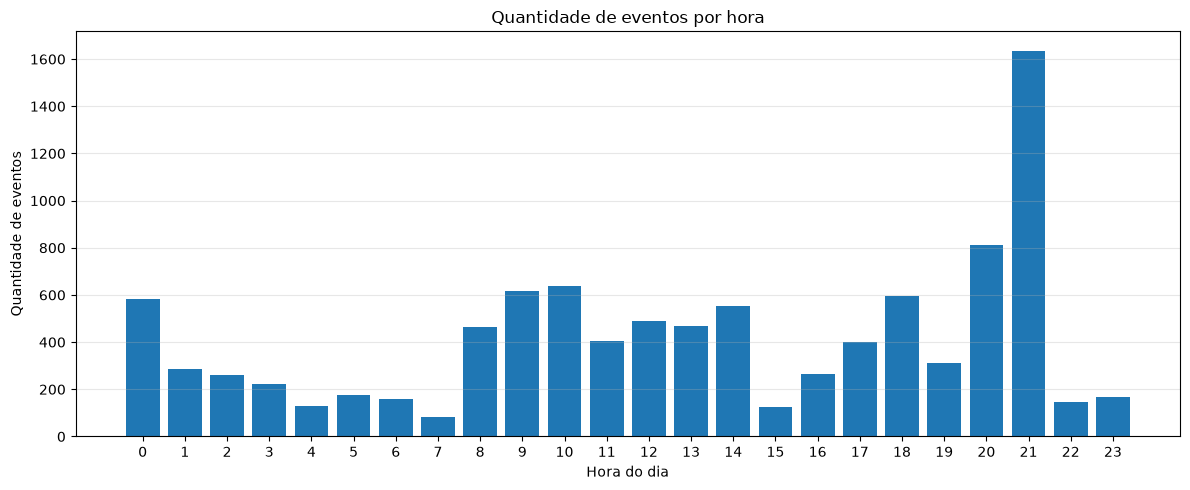

In [73]:
eventos_por_hora = (df["hora_do_dia"].value_counts().sort_index())

plt.figure(figsize=(12, 5))

plt.bar( eventos_por_hora.index,eventos_por_hora.values)

plt.xlabel("Hora do dia")
plt.ylabel("Quantidade de eventos")
plt.title("Quantidade de eventos por hora")

plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()